In [91]:
# Print the decision boundary of a neural network.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap


In [92]:

def one_hot_encode(Y):
    n_labels = Y.shape[0]
    result = np.zeros((n_labels, 2))
    for i in range(n_labels):
        result[i][Y[i]] = 1
    return result


In [93]:

# Uncomment one of the next three lines to decide which dataset to load
x1, x2, y = np.loadtxt('../Datasets/linearly_separable.txt', skiprows=1, unpack=True)
# x1, x2, y = np.loadtxt('non_linearly_separable.txt', skiprows=1, unpack=True)
# x1, x2, y = np.loadtxt('circles.txt', skiprows=1, unpack=True)

X_train = X_test = np.column_stack((x1, x2))
Y_train_unencoded = Y_test = y.astype(int).reshape(-1, 1)
Y_train = one_hot_encode(Y_train_unencoded)


In [94]:
# Generate a mesh over one-dimensional data
# (The mesh() and plot_boundary() functionality were inspired by the
# documentation of the BSD-licensed scikit-learn library.)
def mesh(values):
    range = values.max() - values.min()
    padding_percent = 5
    padding = range * padding_percent * 0.01
    resolution = 1000
    interval = (range + 2 * range * padding) / resolution
    return np.arange(values.min() - padding, values.max() + padding, interval)


def plot_data_by_label(input_variables, labels, label_selector, symbol):
    points = input_variables[(labels == label_selector).flatten()]
    plt.plot(points[:, 0], points[:, 1], symbol, markersize=4)


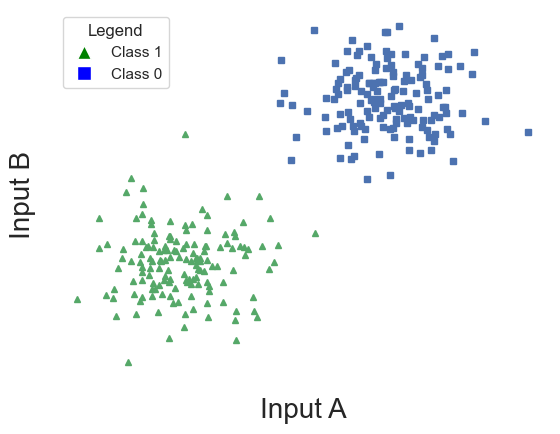

In [95]:
plot_data_by_label(X_train, Y_train_unencoded, 0, 'bs')
plot_data_by_label(X_train, Y_train_unencoded, 1, 'g^')
plt.gca().axes.set_xlabel("Input A", fontsize=20)
plt.gca().axes.set_ylabel("Input B", fontsize=20)
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='Class 1',
           markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Class 0',
           markerfacecolor='blue', markersize=10)
]
plt.legend(loc='upper left', handles=legend_elements,title='Legend',frameon=True)
plt.show()


In [97]:
import numpy as np

# Applying Logistic Regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# performing Forward-Propagation
def forward(X, w):
    weighted_sum = np.matmul(X, w)
    return sigmoid(weighted_sum)

# Calling the predict() function
def classify(X, w):
    y_hat = forward(X, w)
    labels = np.argmax(y_hat, axis=1)
    return labels.reshape(-1, 1)

# Computing Loss 
def loss(X, Y, w):
    y_hat = forward(X, w)
    first_term = Y * np.log(y_hat)
    second_term = (1 - Y) * np.log(1 - y_hat)
    return -np.sum(first_term + second_term) / X.shape[0]

# Calculating gradient
def gradient(X, Y, w):
    return np.matmul(X.T, (forward(X, w) - Y)) / X.shape[0]

# Adding a bias
def prepend_bias(X):
    return np.insert(X, 0, 1, axis=1)

# print function for printing each iteration's log
def report(iteration, X_train, Y_train, X_test, Y_test, w):
    matches = np.count_nonzero(classify(X_test, w) == Y_test)
    n_test_examples = Y_test.shape[0]
    matches = matches * 100.0 / n_test_examples
    training_loss = loss(X_train, Y_train, w)
    print("%d - Loss: %.20f, %.2f%%" % (iteration, training_loss, matches))

# training phase
def train(X_train, Y_train, X_test, Y_test, iterations, lr):
    w = np.zeros((X_train.shape[1], Y_train.shape[1]))
    for iteration in range(iterations):
        report(iteration, X_train, Y_train, X_test, Y_test, w)
        w -= gradient(X_train, Y_train, w) * lr
    report(iteration, X_train, Y_train, X_test, Y_test, w)
    return w


In [98]:
# Caling the training function 
X_train = X_test = prepend_bias(np.column_stack((x1,x2)))
w = train(X_train, Y_train, X_test, Y_test, 
                                  iterations=10, lr=0.1)

0 - Loss: 1.38629436111989057245, 50.00%
1 - Loss: 1.29274511217352139347, 100.00%
2 - Loss: 1.20866271434718486333, 100.00%
3 - Loss: 1.13302765816415784705, 100.00%
4 - Loss: 1.06489960137581718413, 100.00%
5 - Loss: 1.00342509385425948665, 100.00%
6 - Loss: 0.94783895257848982396, 100.00%
7 - Loss: 0.89746132731355676704, 100.00%
8 - Loss: 0.85169212448653142111, 100.00%
9 - Loss: 0.81000404117103352863, 100.00%
9 - Loss: 0.77193508429749002620, 100.00%


In [99]:
w

array([[ 0.00049145, -0.00049145],
       [ 0.3902336 , -0.3902336 ],
       [ 0.39520496, -0.39520496]])

In [100]:
w0,w1,w2 = w[0,0],w[1,0],w[2,0]
x1_vals = np.linspace(X_train[:,1].min(),X_train[:,1].max(),301)
x2_vals = -(w1 * x1_vals + w0) / w2

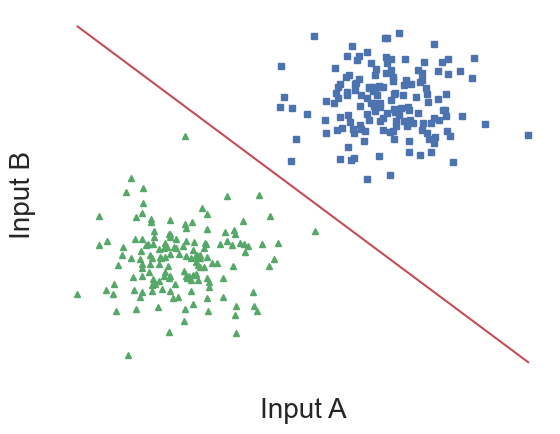

In [101]:
plot_data_by_label(X_train[:,1:], Y_train_unencoded, 0, 'bs')
plot_data_by_label(X_train[:,1:], Y_train_unencoded, 1, 'g^')
plt.gca().axes.set_xlabel("Input A", fontsize=20)
plt.gca().axes.set_ylabel("Input B", fontsize=20)
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.plot(x1_vals, x2_vals, 'r-', label='Decision Boundary')
plt.show()

Calculating boundary...


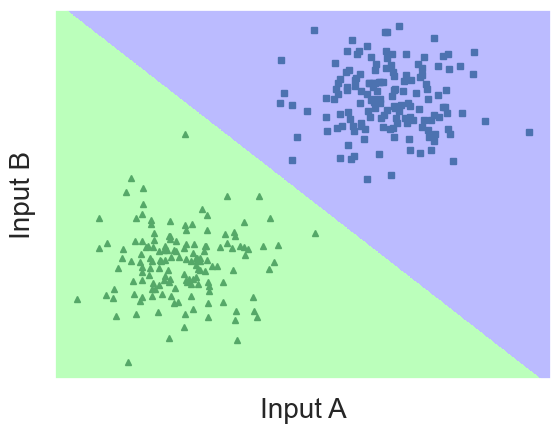

In [103]:
# Generate a mesh over one-dimensional data
# (The mesh() and plot_boundary() functionality were inspired by the
# documentation of the BSD-licensed scikit-learn library.)
def mesh(values):
    range = values.max() - values.min()
    padding_percent = 5
    padding = range * padding_percent * 0.01
    resolution = 1000
    interval = (range + 2 * range * padding) / resolution
    return np.arange(values.min() - padding, values.max() + padding, interval)


def plot_boundary(points, w):
    print("Calculating boundary...")
    # Generate a grid of points over the data
    x_mesh = mesh(points[:, 1])
    y_mesh = mesh(points[:, 2])
    grid_x, grid_y = np.meshgrid(x_mesh, y_mesh)
    grid = np.c_[grid_x.ravel(), grid_y.ravel()]
    # Classify points in the grid
    classifications = classify(
                      prepend_bias(grid), w).reshape(grid_x.shape)
    # Trace the decision boundary
    BLUE_AND_GREEN = ListedColormap(['#BBBBFF', '#BBFFBB'])
    plt.contourf(grid_x, grid_y, classifications, cmap=BLUE_AND_GREEN)


def plot_data_by_label(input_variables, labels, label_selector, symbol):
    points = input_variables[(labels == label_selector).flatten()]
    plt.plot(points[:, 1], points[:, 2], symbol, markersize=4)


plot_boundary(X_train, w)
plot_data_by_label(X_train, Y_train_unencoded, 0, 'bs')
plot_data_by_label(X_train, Y_train_unencoded, 1, 'g^')
plt.gca().axes.set_xlabel("Input A", fontsize=20)
plt.gca().axes.set_ylabel("Input B", fontsize=20)
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

No matter how much we change a perceptron’s weights, its decision boundary will always be a straight line. Perceptrons don’t do curves.

We are talking about a straight line because the datasets in these examples have two input variables. If they had more, then the boundary would be the higher-dimensional equivalent of a line, like a three-dimensional plane, or a 
785-dimensional hyperplane. However, we can agree to be informal and say a perceptron’s decision boundary is a straight line for all those cases.

A Straight Line is not enough

Check the below data plot. Can you seperate with straight line?

In [117]:
# Uncomment one of the next three lines to decide which dataset to load
#x1, x2, y = np.loadtxt('../Datasets/linearly_separable.txt', skiprows=1, unpack=True)
x1, x2, y = np.loadtxt('../Datasets/non_linearly_separable.txt', skiprows=1, unpack=True)
# x1, x2, y = np.loadtxt('circles.txt', skiprows=1, unpack=True)

X_train =  X_test = np.column_stack((x1, x2))
Y_train_unencoded = Y_test = y.astype(int).reshape(-1, 1)
Y_train = one_hot_encode(Y_train_unencoded)

In [118]:
# Generate a mesh over one-dimensional data
# (The mesh() and plot_boundary() functionality were inspired by the
# documentation of the BSD-licensed scikit-learn library.)
def mesh(values):
    range = values.max() - values.min()
    padding_percent = 5
    padding = range * padding_percent * 0.01
    resolution = 1000
    interval = (range + 2 * range * padding) / resolution
    return np.arange(values.min() - padding, values.max() + padding, interval)


def plot_data_by_label(input_variables, labels, label_selector, symbol):
    points = input_variables[(labels == label_selector).flatten()]
    plt.plot(points[:, 0], points[:, 1], symbol, markersize=4)

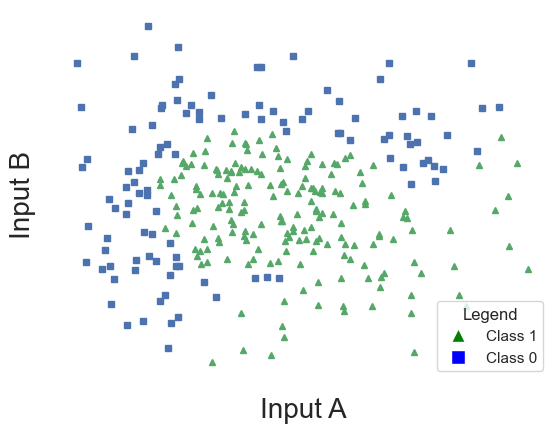

In [119]:
plot_data_by_label(X_train, Y_train_unencoded, 0, 'bs')
plot_data_by_label(X_train, Y_train_unencoded, 1, 'g^')
plt.gca().axes.set_xlabel("Input A", fontsize=20)
plt.gca().axes.set_ylabel("Input B", fontsize=20)
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='Class 1',
           markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Class 0',
           markerfacecolor='blue', markersize=10)
]
plt.legend(loc='lower right', handles=legend_elements,title='Legend',frameon=True)
plt.show()

In [120]:
#prepending bias to it
X_train = X_test = prepend_bias(np.column_stack((x1, x2)))


# Caling the training function 
w = train(X_train, Y_train, X_test, Y_test, 
                                  iterations=10000, lr=0.1)

0 - Loss: 1.38629436111989057245, 36.00%
1 - Loss: 1.38092065346487014033, 64.00%
2 - Loss: 1.37589393258097247852, 64.00%
3 - Loss: 1.37119091622943578557, 64.00%
4 - Loss: 1.36678984296631744755, 64.00%
5 - Loss: 1.36267038342843949117, 64.00%
6 - Loss: 1.35881355481401855378, 64.00%
7 - Loss: 1.35520163881123356653, 64.00%
8 - Loss: 1.35181810314213635138, 64.00%
9 - Loss: 1.34864752681787503086, 64.00%
10 - Loss: 1.34567552914239030315, 64.00%
11 - Loss: 1.34288870245394575953, 64.00%
12 - Loss: 1.34027454855554162272, 64.00%
13 - Loss: 1.33782141875510096618, 64.00%
14 - Loss: 1.33551845741304675563, 64.00%
15 - Loss: 1.33335554887748108932, 64.00%
16 - Loss: 1.33132326767463449180, 64.00%
17 - Loss: 1.32941283181377034595, 64.00%
18 - Loss: 1.32761605906058899329, 64.00%
19 - Loss: 1.32592532603074619857, 64.00%
20 - Loss: 1.32433352995486464110, 64.00%
21 - Loss: 1.32283405296792633266, 64.00%
22 - Loss: 1.32142072877880223380, 64.00%
23 - Loss: 1.32008781157958909880, 64.00%
24

In [121]:
w0,w1,w2 = w[0,0],w[1,0],w[2,0]
x1_vals = np.linspace(X_train[:,1].min(),X_train[:,1].max(),301)
x2_vals = -(w1 * x1_vals + w0) / w2

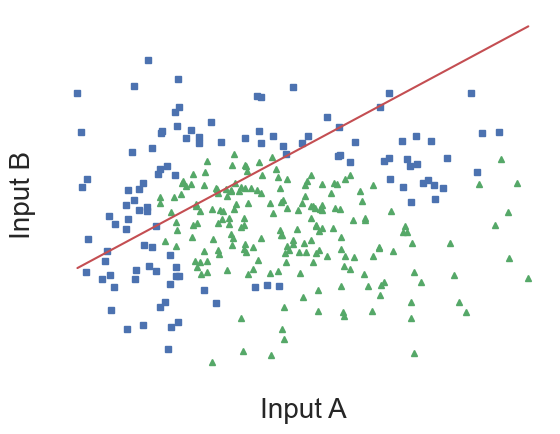

In [122]:
plot_data_by_label(X_train[:,1:], Y_train_unencoded, 0, 'bs')
plot_data_by_label(X_train[:,1:], Y_train_unencoded, 1, 'g^')
plt.gca().axes.set_xlabel("Input A", fontsize=20)
plt.gca().axes.set_ylabel("Input B", fontsize=20)
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.plot(x1_vals, x2_vals, 'r-', label='Decision Boundary')
plt.show()

See perceptron can't!!!

Let's Bend the boundary with neural network

In [123]:
# A neural network implementation.


# Applying Logistic Regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def softmax(logits):
    exponentials = np.exp(logits)
    return exponentials / np.sum(exponentials, axis=1).reshape(-1, 1)

# Calculating gradient over sigmoid
def sigmoid_gradient(sigmoid):
    return np.multiply(sigmoid, (1 - sigmoid))

# Computing Loss 
def loss(Y, y_hat):
    return -np.sum(Y * np.log(y_hat)) / Y.shape[0]

# Adding a bias
def prepend_bias(X):
    return np.insert(X, 0, 1, axis=1)

# performing Forward-Propagation
def forward(X, w1, w2):
    h = sigmoid(np.matmul(prepend_bias(X), w1))
    y_hat = softmax(np.matmul(prepend_bias(h), w2))
    return (y_hat, h)

# performing back-Propagation
def back(X, Y, y_hat, w2, h):
    w2_gradient = np.matmul(prepend_bias(h).T, (y_hat - Y)) / X.shape[0]
    w1_gradient = np.matmul(prepend_bias(X).T, np.matmul(y_hat - Y, w2[1:].T)
                            * sigmoid_gradient(h)) / X.shape[0]
    return (w1_gradient, w2_gradient)

# Calling the predict() function
def classify(X, w1, w2):
    y_hat, _ = forward(X, w1, w2)
    labels = np.argmax(y_hat, axis=1)
    return labels.reshape(-1, 1)

# Initializing random weights for each node
def initialize_weights(n_input_variables, n_hidden_nodes, n_classes):
    w1_rows = n_input_variables + 1
    # np.random.seed(42)
    w1 = np.random.randn(w1_rows, n_hidden_nodes) * np.sqrt(1 / w1_rows)

    w2_rows = n_hidden_nodes + 1
    w2 = np.random.randn(w2_rows, n_classes) * np.sqrt(1 / w2_rows)

    return (w1, w2)

# Log function for printing details of each epochs
def report(iteration, X_train, Y_train, X_test, Y_test, w1, w2):
    y_hat, _ = forward(X_train, w1, w2)
    training_loss = loss(Y_train, y_hat)
    classifications = classify(X_test, w1, w2)
    accuracy = np.average(classifications == Y_test) * 100.0
    print("Iteration: %5d, Loss: %.8f, Accuracy: %.2f%%" %
          (iteration, training_loss, accuracy))

# Taining phase for the classifier
def train(X_train, Y_train, X_test, Y_test, n_hidden_nodes, iterations, lr):
    n_input_variables = X_train.shape[1]
    n_classes = Y_train.shape[1]
    w1, w2 = initialize_weights(n_input_variables, n_hidden_nodes, n_classes)
    for iteration in range(iterations):
        y_hat, h = forward(X_train, w1, w2)
        w1_gradient, w2_gradient = back(X_train, Y_train, y_hat, w2, h)
        w1 = w1 - (w1_gradient * lr)
        w2 = w2 - (w2_gradient * lr)
        report(iteration, X_train, Y_train, X_test, Y_test, w1, w2)
    return (w1, w2)

In [124]:

# One hot encoding 
def one_hot_encode(Y):
    n_labels = Y.shape[0]
    result = np.zeros((n_labels, 2))
    for i in range(n_labels):
        result[i][Y[i]] = 1
    return result
    
# Loading no-linear data
x1, x2, y = np.loadtxt('../Datasets/non_linearly_separable.txt', skiprows=1, unpack=True)


In [125]:
# Performing One-Hot Encoding and then training the classifier
X_train = X_test = np.column_stack((x1, x2))
Y_train_unencoded = Y_test = y.astype(int).reshape(-1, 1)
Y_train = one_hot_encode(Y_train_unencoded)
w1, w2 = train(X_train, Y_train,
                  X_test, Y_test,
                  n_hidden_nodes=10, iterations=10000, lr=0.3)

Iteration:     0, Loss: 0.64975530, Accuracy: 64.00%
Iteration:     1, Loss: 0.64851282, Accuracy: 64.00%
Iteration:     2, Loss: 0.64820901, Accuracy: 64.00%
Iteration:     3, Loss: 0.64807830, Accuracy: 64.00%
Iteration:     4, Loss: 0.64798038, Accuracy: 64.00%
Iteration:     5, Loss: 0.64788869, Accuracy: 64.00%
Iteration:     6, Loss: 0.64779815, Accuracy: 64.00%
Iteration:     7, Loss: 0.64770775, Accuracy: 64.00%
Iteration:     8, Loss: 0.64761732, Accuracy: 64.00%
Iteration:     9, Loss: 0.64752681, Accuracy: 64.00%
Iteration:    10, Loss: 0.64743620, Accuracy: 64.00%
Iteration:    11, Loss: 0.64734550, Accuracy: 64.00%
Iteration:    12, Loss: 0.64725471, Accuracy: 64.00%
Iteration:    13, Loss: 0.64716381, Accuracy: 64.00%
Iteration:    14, Loss: 0.64707282, Accuracy: 64.00%
Iteration:    15, Loss: 0.64698172, Accuracy: 64.00%
Iteration:    16, Loss: 0.64689051, Accuracy: 64.00%
Iteration:    17, Loss: 0.64679919, Accuracy: 64.00%
Iteration:    18, Loss: 0.64670777, Accuracy: 

In [126]:
# Generate a mesh over one-dimensional data
# (The mesh() and plot_boundary() functionality were inspired by the
# documentation of the BSD-licensed scikit-learn library.)
def mesh(values):
    range = values.max() - values.min()
    padding_percent = 5
    padding = range * padding_percent * 0.01
    resolution = 1000
    interval = (range + 2 * range * padding) / resolution
    return np.arange(values.min() - padding, values.max() + padding, interval)


def plot_boundary(points, w1, w2):
    print("Calculating boundary...")
    # Generate a grid of points over the data
    x_mesh = mesh(points[:, 0])
    y_mesh = mesh(points[:, 1])
    grid_x, grid_y = np.meshgrid(x_mesh, y_mesh)
    grid = np.c_[grid_x.ravel(), grid_y.ravel()]
    # Classify points in the grid
    classifications = classify(grid, w1, w2).reshape(grid_x.shape)
    # Trace the decision boundary
    BLUE_AND_GREEN = ListedColormap(['#BBBBFF', '#BBFFBB'])
    plt.contourf(grid_x, grid_y, classifications, cmap=BLUE_AND_GREEN)


def plot_data_by_label(input_variables, labels, label_selector, symbol):
    points = input_variables[(labels == label_selector).flatten()]
    plt.plot(points[:, 0], points[:, 1], symbol, markersize=4)


Calculating boundary...


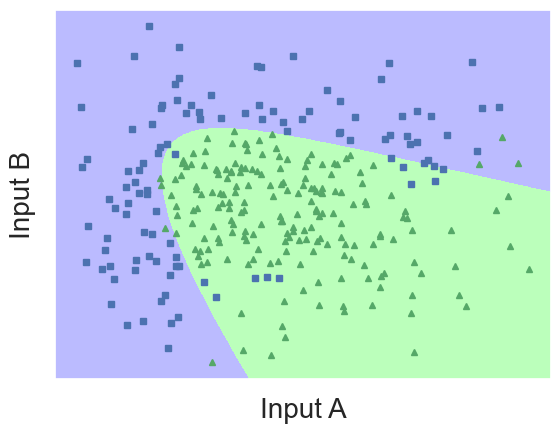

In [127]:
plot_boundary(X_train, w1, w2)
plot_data_by_label(X_train, Y_train_unencoded, 0, 'bs')
plot_data_by_label(X_train, Y_train_unencoded, 1, 'g^')
plt.gca().axes.set_xlabel("Input A", fontsize=20)
plt.gca().axes.set_ylabel("Input B", fontsize=20)
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

In [128]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
sns.set()

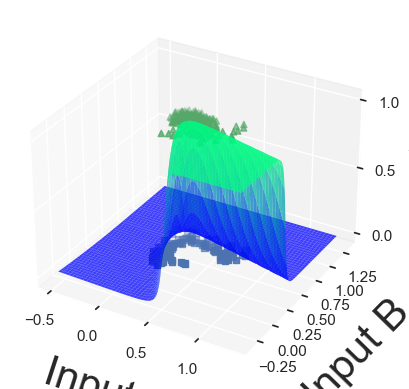

In [129]:
# Plot the axes
sns.set(rc={"axes.facecolor": "white", "figure.facecolor": "white"})
fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")
ax.set_zticks([0, 0.5, 1])
ax.set_xlabel("Input A", labelpad=15, fontsize=30)
ax.set_ylabel("Input B", labelpad=15, fontsize=30)
ax.set_zlabel("ŷ", labelpad=5, fontsize=30)

# Plot the data points
blue_squares = X_train[(Y_train_unencoded == 0).flatten()]
ax.scatter(blue_squares[:, 0], blue_squares[:, 1], 0, c='b', marker='s')
green_triangles = X_train[(Y_train_unencoded == 1).flatten()]
ax.scatter(green_triangles[:, 0], green_triangles[:, 1], 1, c='g', marker='^')

# Plot the model
MARGIN = 0.5
MESH_SIZE = 1000  # This model has a lot of detail, so we need a hi-res mesh
x, y = np.meshgrid(np.linspace(x1.min() - MARGIN, x1.max() + MARGIN, MESH_SIZE),
                   np.linspace(x2.min() - MARGIN, x2.max() + MARGIN, MESH_SIZE))
grid = zip(np.ravel(x), np.ravel(y))
# Calculate all the outputs of forward(), in the format (y_hat, h):
forwards = [forward(np.column_stack(([i], [j])), w1, w2) for i, j in grid]
# For each (y_hat, y), keep only the second column of y_hat:
z = np.array([y_hat for y_hat, h in forwards])[:, 0, 1]
z = z.reshape((MESH_SIZE, MESH_SIZE))
ax.plot_surface(x, y, z, alpha=0.75, cmap=cm.winter,
                linewidth=0, antialiased=True)
plt.show()


In [130]:
# Loading no-linear data
x1, x2, y = np.loadtxt('../Datasets/Circles.txt', skiprows=1, unpack=True)

# Performing One-Hot Encoding and then training the classifier
X_train = X_test = np.column_stack((x1, x2))
Y_train_unencoded = Y_test = y.astype(int).reshape(-1, 1)
Y_train = one_hot_encode(Y_train_unencoded)
w1, w2 = train(X_train, Y_train,
                  X_test, Y_test,
                  n_hidden_nodes=10, iterations=10000, lr=0.3)


Iteration:     0, Loss: 0.70521023, Accuracy: 49.00%
Iteration:     1, Loss: 0.69993565, Accuracy: 49.67%
Iteration:     2, Loss: 0.69867474, Accuracy: 50.00%
Iteration:     3, Loss: 0.69827055, Accuracy: 50.00%
Iteration:     4, Loss: 0.69804927, Accuracy: 50.33%
Iteration:     5, Loss: 0.69786965, Accuracy: 50.00%
Iteration:     6, Loss: 0.69770213, Accuracy: 50.00%
Iteration:     7, Loss: 0.69754045, Accuracy: 50.00%
Iteration:     8, Loss: 0.69738321, Accuracy: 50.00%
Iteration:     9, Loss: 0.69723002, Accuracy: 50.00%
Iteration:    10, Loss: 0.69708068, Accuracy: 50.00%
Iteration:    11, Loss: 0.69693506, Accuracy: 50.00%
Iteration:    12, Loss: 0.69679305, Accuracy: 49.67%
Iteration:    13, Loss: 0.69665453, Accuracy: 49.67%
Iteration:    14, Loss: 0.69651938, Accuracy: 49.67%
Iteration:    15, Loss: 0.69638751, Accuracy: 49.67%
Iteration:    16, Loss: 0.69625880, Accuracy: 49.67%
Iteration:    17, Loss: 0.69613317, Accuracy: 49.67%
Iteration:    18, Loss: 0.69601052, Accuracy: 

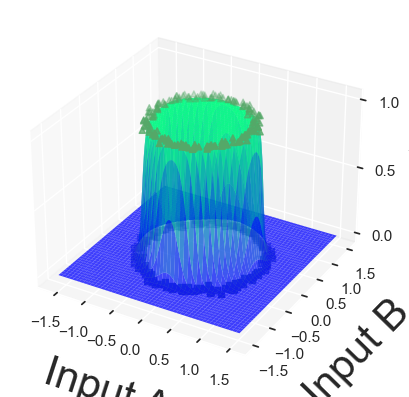

In [131]:
# Plot the axes
sns.set(rc={"axes.facecolor": "white", "figure.facecolor": "white"})
fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")
ax.set_zticks([0, 0.5, 1])
ax.set_xlabel("Input A", labelpad=15, fontsize=30)
ax.set_ylabel("Input B", labelpad=15, fontsize=30)
ax.set_zlabel("ŷ", labelpad=5, fontsize=30)

# Plot the data points
blue_squares = X_train[(Y_train_unencoded == 0).flatten()]
ax.scatter(blue_squares[:, 0], blue_squares[:, 1], 0, c='b', marker='s')
green_triangles = X_train[(Y_train_unencoded == 1).flatten()]
ax.scatter(green_triangles[:, 0], green_triangles[:, 1], 1, c='g', marker='^')

# Plot the model
MARGIN = 0.5
MESH_SIZE = 1000  # This model has a lot of detail, so we need a hi-res mesh
x, y = np.meshgrid(np.linspace(x1.min() - MARGIN, x1.max() + MARGIN, MESH_SIZE),
                   np.linspace(x2.min() - MARGIN, x2.max() + MARGIN, MESH_SIZE))
grid = zip(np.ravel(x), np.ravel(y))
# Calculate all the outputs of forward(), in the format (y_hat, h):
forwards = [forward(np.column_stack(([i], [j])), w1, w2) for i, j in grid]
# For each (y_hat, y), keep only the second column of y_hat:
z = np.array([y_hat for y_hat, h in forwards])[:, 0, 1]
z = z.reshape((MESH_SIZE, MESH_SIZE))
ax.plot_surface(x, y, z, alpha=0.75, cmap=cm.winter,
                linewidth=0, antialiased=True)
plt.show()


Calculating boundary...


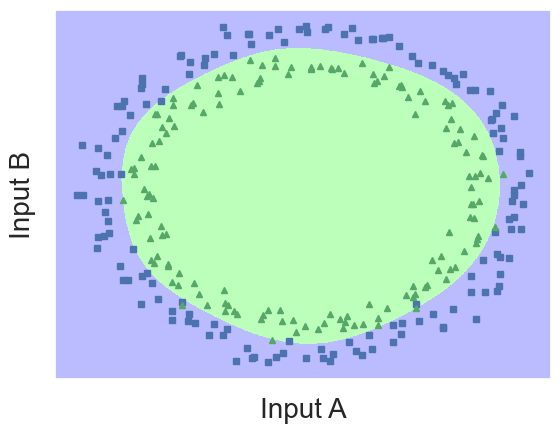

In [132]:
plot_boundary(X_train, w1, w2)
plot_data_by_label(X_train, Y_train_unencoded, 0, 'bs')
plot_data_by_label(X_train, Y_train_unencoded, 1, 'g^')
plt.gca().axes.set_xlabel("Input A", fontsize=20)
plt.gca().axes.set_ylabel("Input B", fontsize=20)
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()